In [ ]:
import pandas as pd

df = pd.read_excel("Cleaned_Sales_Dataset.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 12)


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [ ]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Total_Sales']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB

Missing Values:
Order_ID      

In [ ]:
df.describe()


,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [ ]:
from scipy import stats

# Hypothesized average sales
hypothesized_mean = 100000

# One-sample t-test
t_stat, p_value = stats.ttest_1samp(
    df["Total_Sales"],
    hypothesized_mean
)

print("One-Sample T-Test")
print("------------------")
print("Hypothesized Mean:", hypothesized_mean)
print("Sample Mean:", df["Total_Sales"].mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

# Decision
alpha = 0.05

if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis (H0)")
    print("There is a statistically significant difference from ₹100,000.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis (H0)")
    print("There is not enough evidence of a significant difference from ₹100,000.")

One-Sample T-Test
------------------
Hypothesized Mean: 100000
Sample Mean: 139399.43965000001
T-statistic: 10.919536506775968
P-value: 2.660655081319836e-26

Result: Reject the Null Hypothesis (H0)
There is a statistically significant difference from ₹100,000.


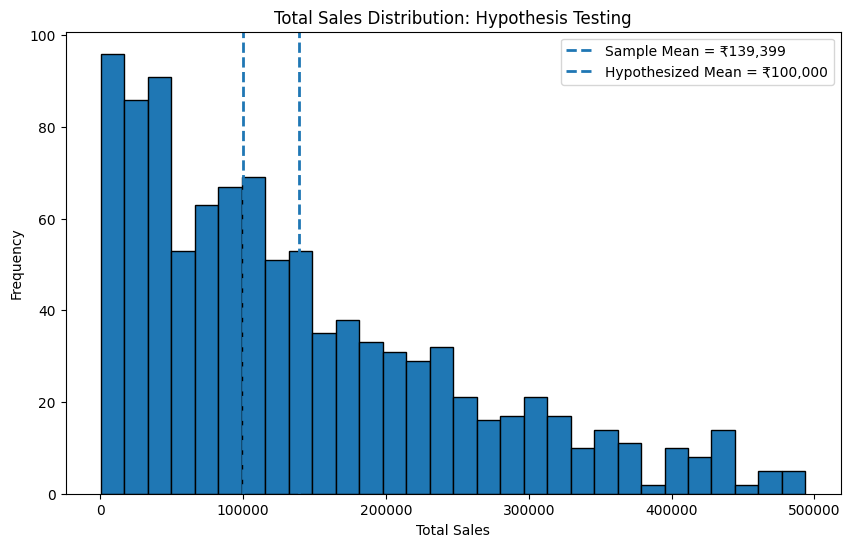

In [ ]:
import matplotlib.pyplot as plt

sample_mean = df["Total_Sales"].mean()
hypothesized_mean = 100000

plt.figure(figsize=(10, 6))

plt.hist(df["Total_Sales"], bins=30, edgecolor="black")

plt.axvline(
    sample_mean,
    linestyle="--",
    linewidth=2,
    label=f"Sample Mean = ₹{sample_mean:,.0f}"
)

plt.axvline(
    hypothesized_mean,
    linestyle="--",
    linewidth=2,
    label="Hypothesized Mean = ₹100,000"
)

plt.title("Total Sales Distribution: Hypothesis Testing")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
from scipy.stats import pearsonr

quantity = df["Quantity"]
total_sales = df["Total_Sales"]

correlation, p_value = pearsonr(quantity, total_sales)

print("Pearson Correlation Test")
print("------------------------")
print("Correlation Coefficient:", correlation)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis (H0)")
    print("There is a statistically significant relationship between Quantity and Total Sales.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis (H0)")
    print("There is not enough evidence of a significant relationship.")

Pearson Correlation Test
------------------------
Correlation Coefficient: 0.6466406163004241
P-value: 1.713608108961374e-119

Result: Reject the Null Hypothesis (H0)
There is a statistically significant relationship between Quantity and Total Sales.


In [ ]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(
    df["Quantity"],
    df["Total_Sales"]
)

print("Correlation coefficient:", correlation)
print("P-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Reject H0")
    print("Quantity and Total Sales have a statistically significant relationship.")
else:
    print("Conclusion: Fail to reject H0")
    print("There is not enough evidence of a significant relationship.")

Correlation coefficient: 0.6466406163004241
P-value: 1.713608108961374e-119
Conclusion: Reject H0
Quantity and Total Sales have a statistically significant relationship.


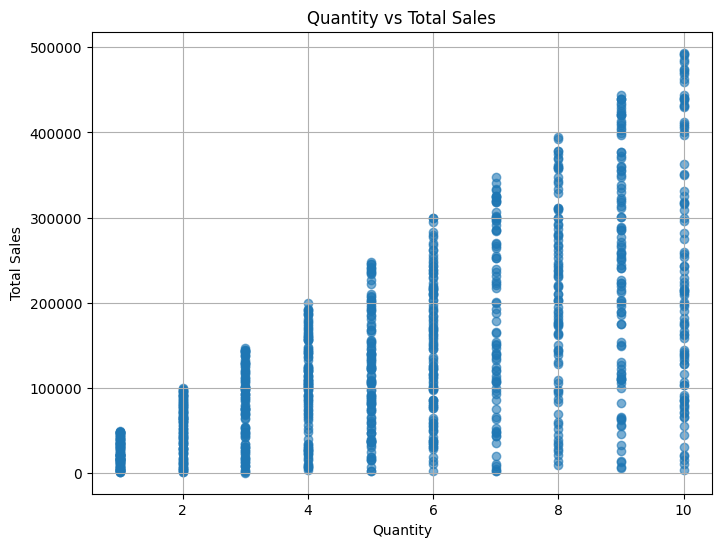

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(df["Quantity"], df["Total_Sales"], alpha=0.6)

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

In [ ]:
results = pd.DataFrame({
    "Test": [
        "One-Sample T-Test",
        "Pearson Correlation"
    ],
    "Variables": [
        "Total_Sales vs ₹100,000",
        "Quantity vs Total_Sales"
    ],
    "Statistic": [
        t_stat,
        correlation
    ],
    "P_Value": [
        2.660655081319836e-26,
        p_value
    ],
    "Significance_Level": [
        0.05,
        0.05
    ]
})

results

,Test,Variables,Statistic,P_Value,Significance_Level
0,One-Sample T-Test,"Total_Sales vs ₹100,000",10.919537,2.660655e-26,0.05
1,Pearson Correlation,Quantity vs Total_Sales,0.646641,1.713608e-119,0.05


In [ ]:
results.to_excel(
    "Task4_Hypothesis_Testing_Results.xlsx",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [ ]:
from google.colab import files

files.download("Task4_Hypothesis_Testing_Results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>